# Prosjekt 2

In [ ]:
import time

start = time.time()

## 1 Exercise

>**Exercise 1a)**

**Exercise 1a)**

The given equation is

$$\frac{d^2}{dx^2}y(x) = -4\sin 2x.$$

Integrating twice gives

$$\frac{d}{dx}y(x) = 2\cos 2x + C, \qquad y(x) = \sin 2x + Cx + D.$$

With the initial conditions $y(0) = 0$ and $y'(0) = 2$ we get $C = 0$ and $D = 0$, so

$$y(x) = \sin 2x.$$


>**Exercise 1b)**

**Exercise 1b)**

Defining the system as

$$\vec{y}(x) = \begin{pmatrix} y(x) \\ y'(x)\end{pmatrix} = \begin{pmatrix} y_1(x) \\ y_2(x)\end{pmatrix},$$

the second-order equation can be written as a first-order system,

$$\frac{d}{dx}\vec{y}(x) = \begin{pmatrix} y_2(x) \\ -4\sin 2x \end{pmatrix},
\qquad
\vec{y}(0) = \begin{pmatrix} 0 \\ 2 \end{pmatrix}.$$


>**Exercise 1c)**

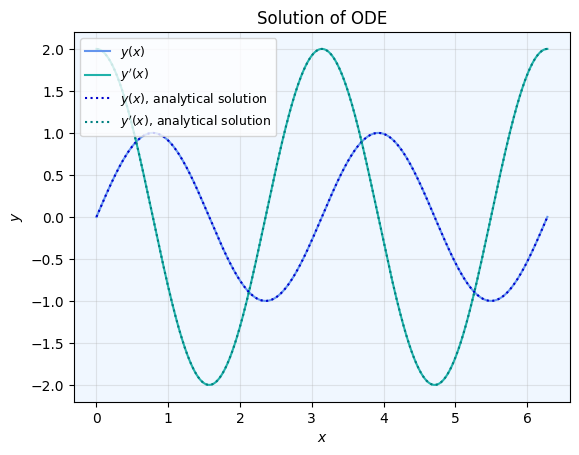

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

alpha = 0.8
tol = 10**(-7)
x_init = 0
x_end = 2*np.pi
y_init = np.array([0,2])
h0 = 0.01 # initial step length

def f(x,y):
    """
    Defines the system of first-order differential equations and
    corresponds to a second-order ODE that has been rewritten as two first-order equations.

    Variables,
        x : Current x-value (float)
        y : Values of [y, y'] (array)

    Returns,
        f_array : Values of [y', y''] (array)
    """
    y1, y2 = y
    f1 = y2                     # Derivative of y
    f2 = -4 * np.sin(2*x)       # Dobbel derivative of y
    f_array = np.array([f1, f2])

    return f_array


def RK3(x_init, x_end, y_init, f, h0, tol, alpha): # Used alpha as a variable as well because of later tasks
    """
    Function for solving a second-order ODE using the Runge-Kutta method

    Variables,
        x_init : Initial x-value (float)
        x_end  : Final x-value (float)
        y_init : Values of [y(x_init), y'(x_init)] (array)
        f      : Function defining the system of first-order differential equations (function)
        h0     : Initial step length (float)
        tol    : Tolerance for the error (float)
        alpha  : Scaling factor for the step length (float)

    Returns,
        x      : x-values (array)
        y      : y-values as a 2D array (array<array>)
        h_list : List of step lengths (list)
    """
    h = h0
    h_list = []

    y = [y_init] # List with 2-dimensional vectors
    x = [x_init] # List with x-values

    k1 = f(x_init, y_init)

    h_accepted = []

    # While x > x_end:
    while x_end - x[-1] > 0:
        h = min(h, x_end - x[-1]) # h is the calculated timestep, unless the timestep is bigger than the last step it takes to get to x_end
        xn = x[-1]                # Uses the last x value in the x array
        yn = y[-1]                # Uses the last y value in the y array

        k2 = f(xn + h/2 , yn + (h/2) * k1)      # Steps in Runge Kutta
        k3 = f(xn + 3*h/4, yn + (3*h*k2)/4)
        yn1 = yn + (h/9) * (2*k1 + 3*k2 + 4*k3) # Calculates new value for y

        xn1 = xn + h
        k4 = f(xn1, yn1)
        zn1 = yn + (h/24)*(7*k1 + 6*k2 + 8*k3 + 3*k4) # Using a more precise method to calculate another value for y

        est = np.linalg.norm(yn1 - zn1)       # Calculating a scalar error estimate
        if est < tol:                         # Checking if the error estimate is small enough
            x.append(xn1)                     # If the estimate is smaller than our tolerance, the new values for x and y are used,
            y.append(yn1)                     # and k1 for the next step will be the value for k4 from this step.
            k1 = k4
            h_accepted.append(h)              # Creates list with all of the accepted timesteps, h
        # If not, a new h will be calculated and xn and yn will be reused
        # Calculates new timestep, h, which is smaller for higher values of est
        # and takes est + 10**(-8) to avoid division by zero:
        h_new = alpha * h * (tol / max(est, 2e-308))**(1/3) # Using max() to avoid division by zero issue
        h = h_new
        h_list.append(h) # Creates a list with all timesteps, regardless of their resulting est

    x = np.array(x)
    y = np.vstack(y)
    return x, y, h_list, h_accepted

x_values, y_values, h_list, h_accepted = RK3(x_init, x_end, y_init, f, h0, tol, alpha)

plt.plot(x_values, y_values[:, 0], label= "$y(x)$", color = 'cornflowerblue')
plt.plot(x_values, y_values[:, 1], label= "$y'(x)$", color = 'lightseagreen')
plt.plot(x_values, np.sin(2*x_values), label= "$y(x)$, analytical solution", color = 'mediumblue',  linestyle = ':')
plt.plot(x_values, 2*np.cos(2*x_values), label= "$y'(x)$, analytical solution", color = 'teal', linestyle = ':')
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.grid(alpha = 0.3)
plt.legend(loc = "upper left", fontsize = 9)
plt.title("Solution of ODE")
plt.gca().set_facecolor("#f0f7ff")
plt.show()

By plotting the analytical solution, we observe that the numerical method is fairly accurate.

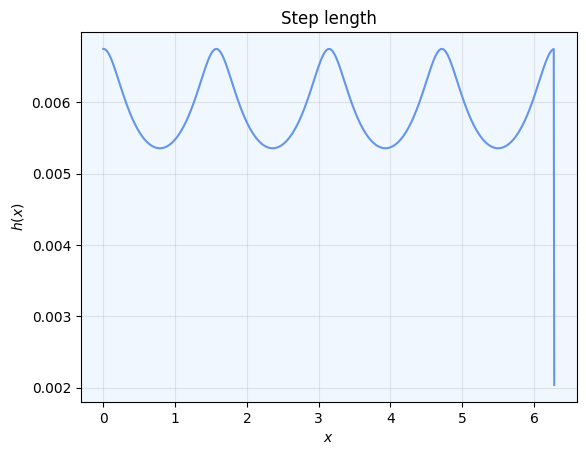

In [ ]:
plt.plot(x_values[:-1], h_accepted, label = "step length, $h(x)$", color = 'cornflowerblue')
plt.xlabel("$x$")
plt.ylabel("$h(x)$")
plt.grid(alpha = 0.3)
plt.title("Step length")
plt.gca().set_facecolor("#f0f7ff")
plt.show()

The step length varies periodically, reaching its maximum when the absolute value of the derivative |$y{\prime}(x)$| is largest, which occurs near the inflection points of $y(x)$. Conversely, the step length is at its minimum near the local extrema of $y(x)$. This behavior can be explained because around the extrema, the curvature of the graph is higher, requiring smaller steps to accurately capture the rapid change in direction. The step length decreases rapidly in the last step beacause it is the last step needed to get to  $x = 2\pi$ and h is therefore x_end - x[-1] which can be much smaller than h.

>**Exercise 1d)**

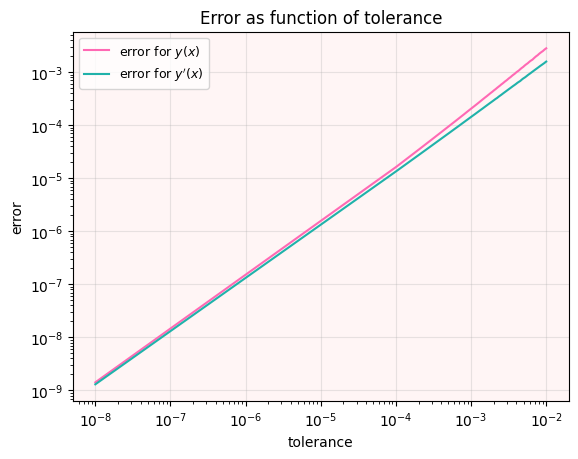

In [ ]:
def error(tol):
    """
    Function for calculating error as function of tolerance

    Variables,
        tol : Different values of tolerance (array)

    Returns,
        y_error_arr    : Error for y(x) (array)
        y_dx_error_arr : Error for y'(x) (array)
    """
    y_error_arr = []      # Creates lists to store errors for y(x) and y'(x)
    y_dx_error_arr = []   # for different values of tolerance
    for t in tol:
        # Calculates numeric values of y(x) and y'(x) for each tolerance in tol array:
        x_num, y_numeric, _ , _= RK3(x_init, x_end, y_init, f, h0, t, alpha)
        y_num = y_numeric[:, 0]
        y_dx_num = y_numeric[:, 1]

        # Calculates analytical values of y(x) and y'(x) for each tolerance in tol array:
        y_anal = np.array(np.sin(2*x_num))
        y_dx_anal = np.array(2*np.cos(2*x_num))

        # Finds the maximum error between analytical and numerical solution:
        y_error = np.max(np.abs(y_num - y_anal))
        y_dx_error = np.max(np.abs(y_dx_num - y_dx_anal))

        y_error_arr.append(y_error)
        y_dx_error_arr.append(y_dx_error)

    # Returns arrays with error for y(x) and y'(x):
    return np.array(y_error_arr), np.array(y_dx_error_arr)

tol_d = np.linspace(0.01, 10**(-8), 100)     # Creates array with different values of tolerance
y_error_arr, y_dx_error_arr = error(tol_d)

plt.plot(tol_d, y_error_arr, color='hotpink', label='error for $y(x)$')
plt.plot(tol_d, y_dx_error_arr, color='lightseagreen', label="error for $y'(x)$")
plt.title("Error as function of tolerance")
plt.xlabel("tolerance")
plt.ylabel("error")
plt.legend(loc = "upper left", fontsize = 9)
plt.grid(alpha = 0.3)
plt.yscale("log")
plt.xscale("log")
plt.gca().set_facecolor("#FFF5F5")
plt.show()

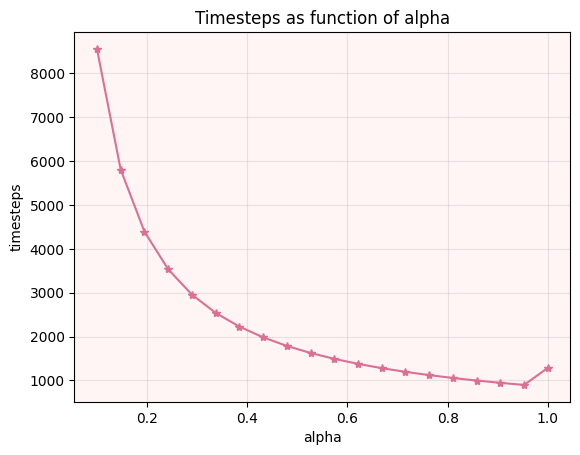

In [ ]:
def timesteps(alpha):
  '''
  Function for calculating the number of timesteps as function of alpha

  Variables,
      alpha : Different values of alpha (array)

  Returns,
      timesteps : Number of timesteps for each value of alpha (array)
  '''
  timesteps = np.zeros(len(alpha)) # Creates array to store number of timesteps per run
  for i, a in enumerate(alpha):
      x_num, y, h, _ = RK3(x_init, x_end, y_init, f, h0, tol, a)
      timesteps[i] = len(h) # Adds number of timesteps for each run (for each value of alpha)
  return timesteps

alpha_d = np.linspace(0.1,1.0,20) # alpha sampled between 0.1 and 1.0; 20 points is enough to show the trend
plt.plot(alpha_d,timesteps(alpha_d), color = 'palevioletred', marker = '*')
plt.title("Timesteps as function of alpha")
plt.xlabel("alpha")
plt.ylabel("timesteps")
plt.grid(alpha = 0.3)
plt.gca().set_facecolor("#FFF5F5")
plt.show()

When alpha is set between 0.1 and 1.0, the computation runs efficiently. However, increasing the upper limit of alpha by as little as 0.01 significantly increases the runtime. This happens because the timestep becomes too large, leading to excessive recalculations. Conversely, when alpha is smaller, the number of timesteps increases due to stricter tolerance, resulting in much smaller step sizes.


>**Exercise 1e)**

In [ ]:
def secant(g, z0, z1, tol):
    '''
    Function for solving root finding problem with the secant method

    Variables,
        g      : The function whose root we are trying to find (function)
        z0, z1 : Inital guesses for the root (float)
        tol    : tolerance (float)

    Returns,
        z : Array with the values of the root (array)
    '''
    z = [z0, z1]
    while abs( z[-2] - z[-1] ) > tol:
        zn = ( z[-2] * g(z[-1]) - z[-1]*g(z[-2]) ) / ( g(z[-1]) - g(z[-2]))
        z.append(zn)

    return z

def g(z):
  '''
  Function g(z) = z + sin(z) + cos(z).
  '''
  return z + np.sin(z) + np.cos(z)

root = secant(g, 0, 1, 10**(-10))[-1] # Gets the last value of the array in the secant function

print("The root calculated with the secant method is", round(root, 4))

The root calculated with the secant method is -0.4566


The analytical answer is approximately $z \approx -0.4566$, so the function is working as intended.


>**Exercise 1f)**

In [ ]:
def g_common(b, func):
    '''
    Function for calculating y(x) with RK3 for different values of b and different functions for defining ODE systems.

    Variables,
        b    : Initial value for y'(0) (float)
        func : Function defining the system of first-order differential equations (function)

    Returns,
        y_values[-1,0] : y(x_end), the last value of y(x) (float)
    '''

    y_init = [0,b]
    y_values = RK3(x_init, x_end, y_init, func, h0, tol, alpha)[1]
    return y_values[-1,0]

g_common was used to avoid duplicating code in g_f and g_g. These functions perform exactly the same tasks but with different functions defining the ODE system. g_common was necessary because the g functions only take one input in the secant method. This approach was chosen because the exercise specified which variables to use in the secant method — otherwise, we would have preferred to modify the input variables in the secant method itself.

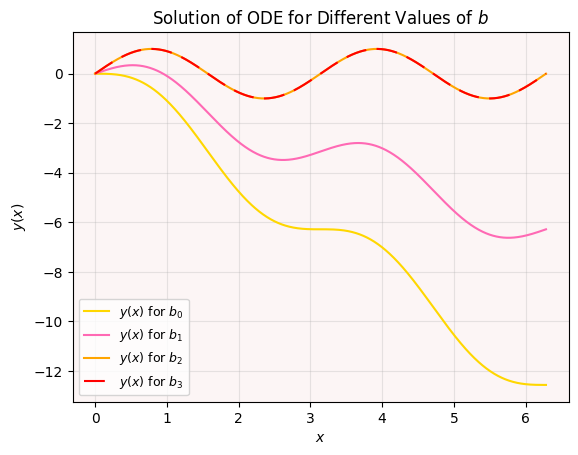

In [ ]:
def g_f(b):
    '''
    Wrapper function for g_f that uses g_common with f

    '''
    return g_common(b, f)

b = secant(g_f,0,1,tol)

# Compute and plot solutions for different values of b
colors = ['gold', 'hotpink', 'orange', 'red']
linestyles = ['-', '-', '-', (0, (10, 5))]

plt.figure()
for i, b in enumerate(b):
    x_val, y_sol, _, _ = RK3(x_init, x_end, [0, b], f, h0, tol, alpha)
    plt.plot(x_val, y_sol[:, 0], label=f"$y(x)$ for $b_{i}$", color=colors[i], linestyle=linestyles[i])

plt.title("Solution of ODE for Different Values of $b$")
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.legend(fontsize=9)
plt.gca().set_facecolor("#fcf5f5")
plt.grid(alpha=0.3)
plt.show()

The plot shows y(x) with different values of y'(0) = b. The graphs for $y(x)$ intersect for $b = b_3$ and $b = b_2$ because $b_2 ≈ b_3$. They are very similar because the secant method runs until $b_2 - b_3 < tol = 10^{-8}$.

>**Exercise 1g)**

In [ ]:
x_init = 0 # New boundary conditions for the last tasks, defining them globally
x_end = 12 # defined globally because several functions below use them

In [ ]:
start1 = time.time()

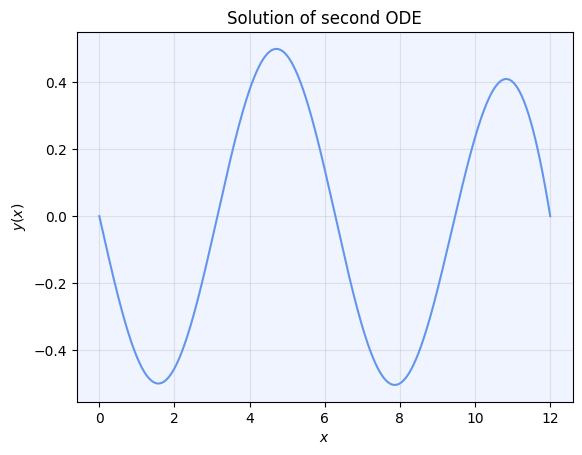

In [ ]:
def g_g(b):
    '''
    Wrapper function for g_f that uses g_common with f_g
    '''
    return g_common(b, f_g)

def f_g(x,y):
    '''
    Function for defining the system of first-order differential equations and
    corresponds to a second-order ODE that has been rewritten as two first-order equations.

    Variables,
        x : Current x-value.
        y : Values of [y, y']

    Returns,
        f : Array containing [y', y'']
    '''
    y1, y2 = y
    f1 = y2
    f2 = y1 + np.sin(x)
    return np.array([f1,f2])

def second_ODE(b0,b1):
    '''
    Function for solving second order differential equation, using the secant function to find
    the value for y'(0) = b.

    Variables,
        b0, b1: Guesses for value of b

    Returns,
        RK3(x_init, x_end, y_init, f_g, h0, tol, alpha): Solution of second order ODE

    '''

    b = secant(g_g,b0,b1,tol)[-1]
    y_init = [0,b]
    return RK3(x_init, x_end, y_init, f_g, h0, tol, alpha)

second_ODE_x, second_ODE_y, _, _ = second_ODE(0,1)

stop1 = time.time()

plt.plot(second_ODE_x, second_ODE_y[:,0], label = "$y(x)$", color = 'cornflowerblue')
plt.title("Solution of second ODE")
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.grid(alpha = 0.3)
plt.gca().set_facecolor("#f0f4ff")
plt.show()

In [ ]:
print(f'Time it takes to solve the ODE with Runge Kutta 3(2) and the secant method: {stop1 - start1}s')

Time it takes to solve the ODE with Runge Kutta 3(2) and the secant method: 5.351158380508423s


>**Exercise 1h)**

In [ ]:
start2 = time.time()

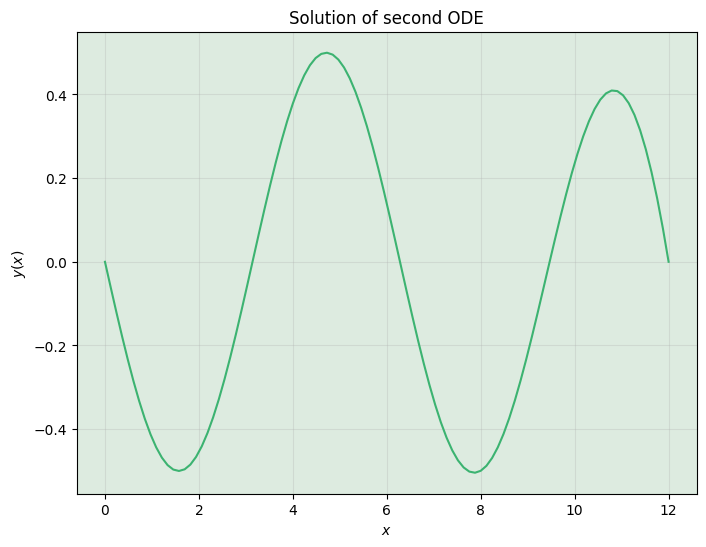

In [ ]:
from scipy.integrate import solve_bvp


def boundary_conditions(y_0, y_end):
    '''
    Function that takes in initial values for y'(x) and y(x)

    Variables,
        y_0 : array-like
            Values of y and y' at the initial boundary x = x_init
        y_end : array-like
            Values of y and y' at the final boundary x = x_end

    Returns,
        array with the values of y(x_init) and y(x_end)
    '''
    return np.array([y_0[0], y_end[0]])

def scipy_solver():
    '''
    Function for solving second order differential equation using scipy's solve_bvp

    Returns,
        solution : Solution of second order ODE
    '''
    x = np.linspace(0,12,100)
    y_guess = np.zeros((2, x.size))
    solution = solve_bvp(f_g,boundary_conditions,x,y_guess)

    return solution

sol = scipy_solver()

stop2 = time.time()

fig, ax = plt.subplots(figsize=(8, 6))

plt.plot(sol.x, sol.y[0], label = "$y(x)$", color = 'mediumseagreen')
plt.title("Solution of second ODE")
plt.xlabel("$x$")
plt.ylabel("$y(x)$")
plt.grid(alpha = 0.3)
plt.gca().set_facecolor("#ddebe0")
plt.show()

In [ ]:
ratio = (stop1 - start1) / (stop2 - start2)
print(f"Time it takes to solve the ODE with scipy's solve_bvp: {stop2 - start2}s")
print(f'Ratio between the times: { ratio }s')

Time it takes to solve the ODE with scipy's solve_bvp: 0.01785564422607422s
Ratio between the times: 299.69002029589274s


We see that it takes approximately 3.8 times longer with the Runge Kutta method than with the scipy solver. Therefore the scipy solver is more efficient.

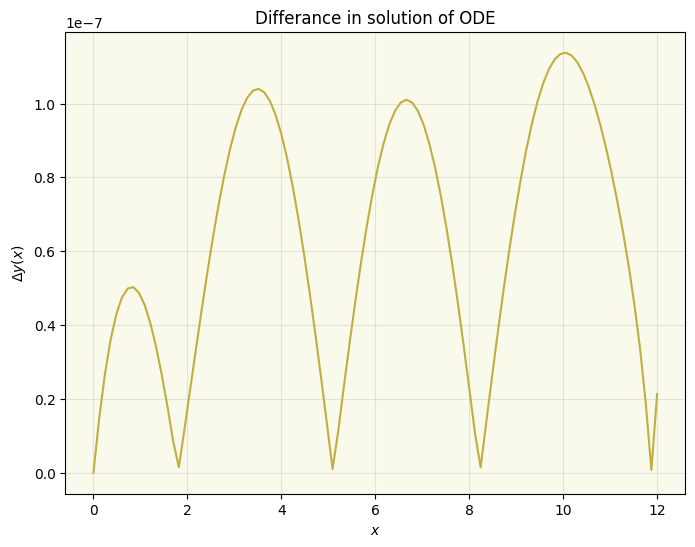

The maximum difference between the two solutions is 1.138e-07
The runtime of the scipy sol


In [ ]:
from scipy.interpolate import interp1d


interpol_scipy = interp1d(sol.x, sol.y[0], kind = 'cubic')
interpol_ODE = interp1d(second_ODE_x, second_ODE_y[:,0], kind = 'cubic')

x_interpol = np.linspace(0,12,100)

y_values_diff = np.abs(interpol_ODE(x_interpol) - interpol_scipy(x_interpol))

fig, ax = plt.subplots(figsize=(8, 6))

plt.plot(x_interpol, y_values_diff, label = "$y(x)$", color = '#c2ae40')
plt.title("Difference in solution of ODE")
plt.xlabel("$x$")
plt.ylabel("${\Delta}y(x)$")
plt.grid(alpha = 0.3)
plt.gca().set_facecolor("#f9faeb")
plt.show()

max_diff = np.max(y_values_diff)
print("The maximum difference between the two solutions is", round(max_diff, 10))


print("The runtime of the scipy sol")

In this plot, we observe two reasons for error. By using the secant method to calculate b, this can cause an error in the solution. This was tested and a lower tolerance in b gives a lower error in $x = x_{end}$. If the value of b differs slightly, the entire solution can be slightly shifted.

Additionally, error can occur due to the difference in degree of the Runge Kutta method and solve_bvp. The Runge Kutta method used is of third degree while scipy's solve_bvp is of fourth degree. This will normally result in higher errors around the extrema, because of the steeper curvature.

However, the error plot shows higher errors near the inflection points than near the extrema. This shows that error in b might be the biggest reason for error. If the shifts of the graph is horizontal, it can lead to larger differences in y where the slope is steep. In contrast, near the extrema, the curve is flatter, so small shifts horizontally have a much smaller effect on the y-values.

As expected, the error is smaller at the beginning. This is because both methods start from the same initial conditions, so any differences between the solutions accumulate gradually as  x  increases

## 2 Exercise

>**Exercise 2a)**

In [ ]:
import numpy as np

def matrix_to_vector(M):
    """
    Transforms a 2x2 complex matrix into an 8-component real vector.

    Variables,
        M : 2x2 complex matrix (array<array>)

    Returns,
        v : 8-component real vector (array)
    """

    v = np.array([ np.real(M[0, 0]), np.real(M[0, 1]), # 8-component real vector from 2x2 complex matrix
        np.real(M[1, 0]), np.real(M[1, 1]),
        np.imag(M[0, 0]), np.imag(M[0, 1]),
        np.imag(M[1, 0]), np.imag(M[1, 1])])

    return v

def vector_to_matrix(v):
    """
    Transforms an 8-component real vector back into a 2x2 complex matrix.

    Variables,
        v : 8-component real vector (array)

    Returns,
        M : 2x2 complex matrix (array<array>)
    """

    M = np.array([[v[0] + 1j * v[4], v[1] + 1j * v[5]],
        [v[2] + 1j * v[6], v[3] + 1j * v[7]]]) # 2x2 complex matrix from 8-component real vector

    return M

In [ ]:
def test_matrix_vector_conversion():
    """
    Test the conversion functions to ensure they are inverse operations.
    """

    M = np.array([[1 + 2j, 3], [-1 - 2j, 3j]]) # Sets a 2x2 complex matrix

    v = matrix_to_vector(M)     # Uses function to turn 2x2 matrix, M, to 8-component real vector, v
    M_rec = vector_to_matrix(v) # Uses inverse function to reconstructed 2x2 matrix, M from the 8-component vector

    assert np.allclose(M, M_rec), "Matrices are not equal. Matrix conversion failed!"  # If the reconstructed matrix is not the same as original matrix,
                                                                                       # it print error message and stops function
    print("Matrix-to-vector and vector-to-matrix transformations work correctly.")     # Prints message if test function worked

# Run tests
test_matrix_vector_conversion()

Matrix-to-vector and vector-to-matrix transformations work correctly.


>**Exercise 2b)**

In [ ]:
def four_vectors_to_32_vector(m1, m2, m3, m4):
    """
    Transforms four 8-component real vectors into a single 32-component real vector.

    Variables,
        m1, m2, m3, m4 : four 8-component real vectors (array)

    Returns,
        v : 32-component real vector (array)
    """

    v = np.concatenate([m1, m2, m3, m4])

    return v

def vector_32_to_four_vectors(v):
    """
    Transforms a 32-component real vector back into four 8-component real vectors.

    Variables,
        v : 32-component real vector (array)

    Returns,
        m1, m2, m3, m4 : four 8-component real vectors (array)
    """

    m1, m2, m3, m4 = v[:8], v[8:16], v[16:24], v[24:]

    return m1, m2, m3, m4

In [ ]:
def test_vector_32_conversion():
    """
    Test the conversion functions to ensure they are inverse operations.
    """

    m1, m2, m3, m4 = np.random.rand(8), np.random.rand(8), np.random.rand(8), np.random.rand(8) # Sets four random 8-component vectors
    v = four_vectors_to_32_vector(m1, m2, m3, m4)                     # Uses function to turn four vectors to a to 32-component vector
    m1_rec, m2_rec, m3_rec, m4_rec = vector_32_to_four_vectors(v)     # Uses inverse function to reconstructed the four vectors from a 32-component vector

    assert np.allclose(m1, m1_rec) and np.allclose(m2, m2_rec) and np.allclose(m3, m3_rec) and np.allclose(m4, m4_rec), \
    "The four vectors are not equal. Four vectors to 32-vector and back conversion failed!" # If the reconstructed vectors are not the same as original vectors,
                                                                                            # it print error message and stops function
    print("Four vectors to 32-vector and back transformations work correctly.")             # Prints message if test function worked

# Run tests
test_vector_32_conversion()

Four vectors to 32-vector and back transformations work correctly.


>**Exercise 2c)**

In [ ]:
def compact_riccati(gamma, gamma_thilde, omega, omega_thilde):
    """
    Takes the four 2x2 complex Riccati-matrices and their derivatives used to
    define the Usadel equation and compactifies them into a single real-valued vector.

    Variables,
        gamma        : As defined in the exercise (array<array>) ?
        gamma_thilde : As defined in the exercise (array<array>)
        omega        : The partial derivative of gamma with respect to x (array<array>)
        omega_thilde : The partial derivative of gamma_thilde with respect to x (array<array>)

    Returns,
        v : Vector of 32 elements with the compactified matrices (array<float>)
    """

    gamma_vec        = matrix_to_vector(gamma)
    gamma_thilde_vec = matrix_to_vector(gamma_thilde)
    omega_vec        = matrix_to_vector(omega)
    omega_thilde_vec = matrix_to_vector(omega_thilde)

    v = np.concatenate([gamma_vec, gamma_thilde_vec, omega_vec, omega_thilde_vec]) # Chose to use concatenate directly
                                                                                   # to avoid unnecessary function calls
    return v


def decompact_riccati(v):
    """
    Takes a 32 element real-valued vector-representation of the Riccati-matrices
    and returns the original 2x2 matrices.

    Variables,
        v : Vector of 32 elements with the compactified matrices (array<float>)

    Returns,
        gamma        : As defined in the exercise (array<array>)
        gamma_thilde : As defined in the exercise (array<array>)
        omega        : The partial derivative of gamma with respect to x (array<array>)
        omega_thilde : The partial derivative of gamma_thilde with respect to x (array<array>)
    """

    gamma_vec, gamma_tilde_vec, omega_vec, omega_tilde_vec = vector_32_to_four_vectors(v)

    gamma        = vector_to_matrix(gamma_vec)
    gamma_tilde  = vector_to_matrix(gamma_tilde_vec)
    omega        = vector_to_matrix(omega_vec)
    omega_tilde  = vector_to_matrix(omega_tilde_vec)

    return gamma, gamma_tilde, omega, omega_tilde

>**Exercise 2d)**

In [ ]:
# Defining the 2x2 identity matrix as a global variable to avoid excessive function calls and reduce runtime
I = np.eye(2, dtype=complex)


def usadel_equation(v, epsilon, delta=0.01):
    """
    Computes the derivative of v(x, epsilon) with respect to x, based on the Usadel equation.

    Variables,
        v       : Vector of 32 elements with the compactified matrices (array<float>)
        epsilon : Variable of dimensionless energy (float)
        delta   : Value of delta, set as 0.01 (float)

    Returns,
        d_v : Derivative of v(x, epsilon) with respect to x (array<float>)
    """

    gamma, gamma_tilde, omega, omega_tilde = decompact_riccati(v)

    d_gamma       = omega
    d_gamma_tilde = omega_tilde

    N       = np.linalg.inv(I - (gamma @ gamma_tilde))       # Calculates the N-matrix for simpler expression for d_omega_tilde
    N_tilde = np.linalg.inv(I - (gamma_tilde @ gamma))       # Calculates the N_tilde-matrix for simpler expression for d_omega

    d_omega       = - 2j * (epsilon + 1j * delta) * gamma - 2 * (omega @ (N_tilde @ (gamma_tilde @ omega)))
    d_omega_tilde = - 2j * (epsilon + 1j * delta) * gamma_tilde - 2 * (omega_tilde @ (N @ (gamma @omega_tilde)))

    d_v = compact_riccati(d_gamma, d_gamma_tilde, d_omega, d_omega_tilde) # Creates d_v from all the partial matrices

    return d_v

>**Exercise 2e)**

In [ ]:
def usadel_rhs(x, vec, epsilon):
    """
    Function defining the right hand side in the numerical solution
    to the Usadel equation.

    Variables,
        x   : Vector of length m, containg the positions in the discretization of the system (array<float>)
        vec : Matrix of dimensions (32,m), containing the derivatives of v at each point in x (array<array>)
        epsilon : Variable of dimensionless energy (float)

    Returns,
        d_vec : Matrix with all the derivatives of the v-vectors in vec (array<array>)
    """

    m = len(x)

    assert vec.shape == (32, m) , "Size error: the size of x and vec is not compatible!"

    d_vec = np.zeros((32,m))

    for i in range(vec.shape[1]): # Looping through all v ectors for each position and calcualting the derivative
      v = vec[:, i]
      d_vec[:, i] = usadel_equation(v, epsilon)

    return d_vec


>**Exercise 2f)**

In [ ]:
def boundary_conditions_normal(v_left, v_right, l, zeta = 3.0):
    """
    Calculating the boundary conditions according to the equations given in the
    exercise sheet for just normal metals. The left one is located at x = 0, and
    the right is located at x = l.

    Variables,
        v_left  : The riccati matrices on vectorized form at the left boundary (array)
        v_right : The riccati matrices on vectorized form at the right boundary (array)
        l       : Normalized length of the normal region (float)
        zeta    : Ratio of interface resistance to bulk resistance, preset to 3.0 (float)

    Returns,
        bc : compactified boundary conditions (array)
    """
    assert len(v_left) == 32 and len(v_right) == 32, "Size error: input size(s) dosn't match the expected size(s)"


    # Using assumptions disscussed below, we get ,

    gamma_0, gamma_tilde_0, omega_0, omega_tilde_0 = decompact_riccati(v_left) # Decompacting v_left
    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = decompact_riccati(v_right)# Decompacting v_right


    # Finding the left side of the given equations by calculating the 4 2x2 matrices
    matrix_1 = omega_0 - (1/(zeta*l))* gamma_0
    matrix_2 = omega_tilde_0 - (1/(zeta*l))* gamma_tilde_0
    matrix_3 = omega_l + (1/(zeta*l))* gamma_l
    matrix_4 = omega_tilde_l + (1/(zeta*l))* gamma_tilde_l

    # Storing the solutions in a single vector
    bc = compact_riccati(matrix_1, matrix_2, matrix_3, matrix_4)

    return bc



>**Exercise 2g)**

In [ ]:
from scipy.integrate import solve_bvp

def solve_usadel_normal(l, m, epsilon):
    """
    Function solving the Usadel equation for normal metals
    using the earlier boundary_conditions_normal, and scipy's solve_bvp.

    Variables,
        l       : Normalized length of the normal region (float)
        m       : Depth of the x-array (int)
        epsilon : Variable of dimensionless energy (float)

    Returns,
        solution : The solution obtained by solving the Usadel equations (object)
    """
    x = np.linspace(0,l,m)
    y = np.zeros((32,m))

    # Finding the solution by passing the rhs and bc with lambda functions to ensure compatibility
    solution = solve_bvp( lambda x, y : usadel_rhs(x,y,epsilon),
                          lambda v_left, v_right: boundary_conditions_normal(v_left, v_right, l),
                          x, y)

    return solution



l = 1
m = 101

epsilon_arr = [0, 1, 2]

# Looping through and simulating for all the given epsilon
for epsilon in epsilon_arr:

    sol = solve_usadel_normal(l, m, epsilon)

    if np.allclose(sol.y, np.zeros((32,m))): # Checking that the solution is numerically zero
        print(f"The solution for epsilon = {epsilon} is numerically identical to zero, as expected.")

    else:
        print(f"The solution for epsilon = {epsilon} is NOT identical to zero, something is wrong!")



The solution for epsilon = 0 is numericly identical to zero, hurray!
The solution for epsilon = 1 is numericly identical to zero, hurray!
The solution for epsilon = 2 is numericly identical to zero, hurray!


>**Exercise 2h)**

In [ ]:
def green_func(v):
    """
    Calculating the green function given a 32 element vector representazation of
    the Riccati matrices and their derivatives.

    Variables,
        v : 32 element vector with the Riccati matrices (array<float>)

    Returns,
        green : 4x4 complex matix representing the green function (array<array>)
    """
    gamma, gamma_tilde, omega, omega_tilde = decompact_riccati(v)

    N = np.linalg.inv(I - (gamma @ gamma_tilde))       # Calculates the N-matrix
    N_tilde = np.linalg.inv(I - (gamma_tilde @ gamma)) # Calculates the N_tilde-matrix

    # Calculating the 4 2x2 matrices that constituts the green function
    m1 = 2*N - I
    m2 = 2*(N @ gamma)
    m3 = -2*(N_tilde @ gamma_tilde)
    m4 = -2*N_tilde + I

    # Composing the full 4x4 matrix from the 4 2x2 matrices
    green = np.block([[ m1 , m2 ],[ m3 , m4 ]])
    return green


def DOS(green_function):
    """
    Function for calculating the Density Of States for a given green function.

    Variables,
        green_function : 4x4 complex matrix representing the green function (array<array>)

    Returns,
        dos : The density of states for the system ()
    """
    rho_3 = np.block([[ I, np.zeros((2,2)) ], [ np.zeros((2,2)), -I ]]) # Defining rho_3 as in the exercise sheet

    trace = np.trace(rho_3 @ green_function) # Calculating the matrix trace of the product

    dos = np.real(trace)/4 #calculates DOS in accordance with the given formula

    return dos

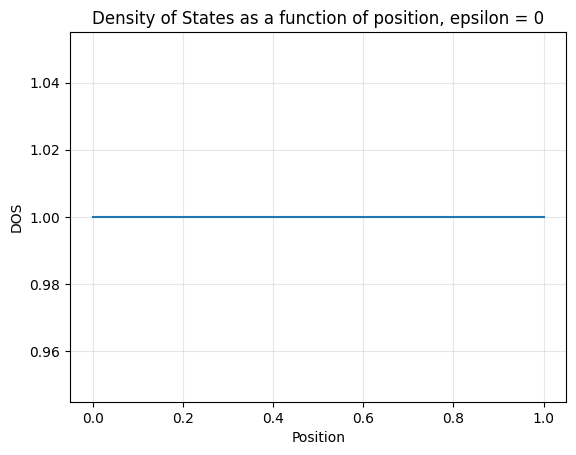

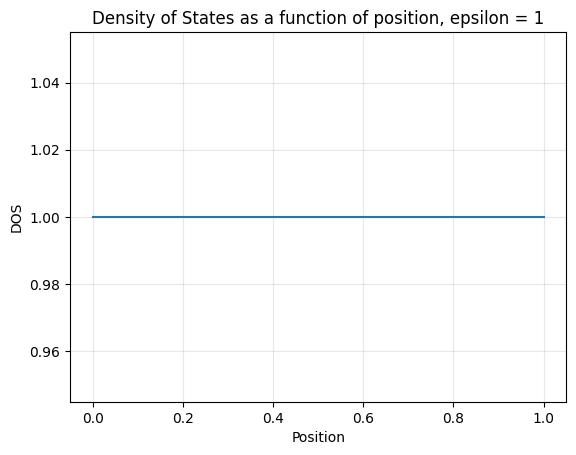

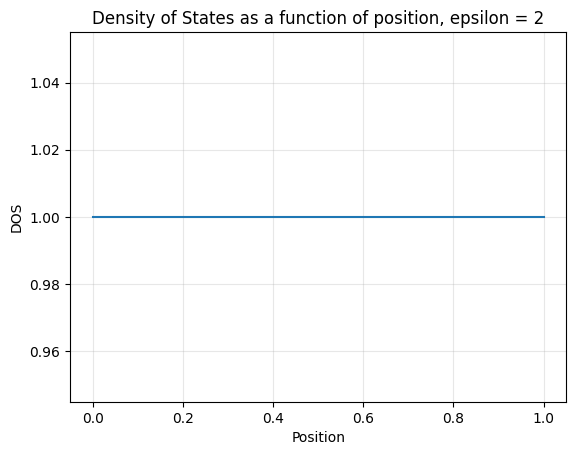

In [ ]:
l = 1
m = 101
x = np.linspace(0,l,m)

epsilon_arr = [0, 1, 2]

for epsilon in epsilon_arr: # looping through the given epsilon

    # Solving and storing the simulated solution to the Usadel equation
    sol = solve_usadel_normal(l, m, epsilon)
    y   = sol.y
    dos_arr = np.zeros(m)

    for i in range(m): # Looping through all the positions and calcualting DOS
        dos_arr[i] = DOS(green_func(y[:,i]))

    plt.plot(x, dos_arr)
    plt.title(f"Density of States as a function of position, epsilon = {epsilon}")
    plt.xlabel("Position")
    plt.ylabel("DOS")
    plt.grid(alpha=0.3)
    plt.show()

The plots show a constant relative density of states, $D(x,\varepsilon)/D_0 = 1$, at every position and for every value of $\varepsilon$.

This is what we expect physically. The region is a normal metal bounded by normal metals, so there is no superconductor anywhere in the system to induce correlations. The number of available electron states per unit energy therefore stays constant throughout the region, and the density of states is simply that of a normal metal everywhere.


>**Exercise 2i)**

In [ ]:
def boundary_conditions_super(v_left, v_right, l, phi_L, phi_R, epsilon, zeta = 3.0, delta = 0.01):
    """
    Calculating the boundary conditions according to the equations given in the
    exercise sheet for two superconductors with a normal metal inbetween.
    The left one is located at x = 0, and the right is located at x = l.

    Variables,
        v_left  : The riccati matrices on vectorized form at the left boundary (array)
        v_right : The riccati matrices on vectorized form at the right boundary (array)
        l       : Normalized length of the normal region (float)
        phi_L   : Phase angle of the left superconductor (float)
        phi_R   : Phase angle of the right superconductor (float)
        epsilon : Variable of dimensionless energy (float)
        zeta    : Ratio of interface resistance to bulk resistance, preset to 3.0 (float)
        delta   : Inelastic scattering, preset to 0.01 (float)

    Returns,
        bc : compactified boundary conditions (array)
    """
    assert len(v_left) == 32 and len(v_right) == 32, "Size error: input size(s) dosn't match the expected size(s)"

    # Defining the helping variables to compute gamma_L, gamma_R etc.
    theta_plus  = np.arctanh( 1/(epsilon + 1j*delta) )
    theta_minus = np.arctanh(-1/(epsilon + 1j*delta) )

    s_plus  = np.sinh(theta_plus)
    s_minus = np.sinh(theta_minus)

    c_plus  = np.cosh(theta_plus)
    c_minus = np.cosh(theta_minus)


    # Calculating gamma_L, gamma_R etc.
    gamma_L = np.array([[0, s_plus/(1+c_plus)] , [s_minus/(1+c_minus) , 0]])* np.exp(1j*phi_L)
    gamma_R = np.array([[0, s_plus/(1+c_plus)] , [s_minus/(1+c_minus) , 0]])* np.exp(1j*phi_R)

    gamma_L_tilde = np.array([[0, s_minus/(1+c_minus)] , [s_plus/(1+c_plus) , 0]])* np.exp(-1j*phi_L)
    gamma_R_tilde = np.array([[0, s_minus/(1+c_minus)] , [s_plus/(1+c_plus) , 0]])* np.exp(-1j*phi_R)


    # Calculating N_L, N_R etc.
    N_L = np.linalg.inv( I - (gamma_L @ gamma_L_tilde))
    N_R = np.linalg.inv( I - (gamma_R @ gamma_R_tilde))

    N_L_tilde = np.linalg.inv( I - (gamma_L_tilde @ gamma_L))
    N_R_tilde = np.linalg.inv( I - (gamma_R_tilde @ gamma_R))

    gamma_0, gamma_tilde_0, omega_0, omega_tilde_0 = decompact_riccati(v_left)  # Decompacting v_left
    gamma_l, gamma_tilde_l, omega_l, omega_tilde_l = decompact_riccati(v_right) # Decompacting v_right


    # Finding the left side of the given equations
    matrix_1 = omega_0 + (1/(zeta*l))* ((I - gamma_0 @ gamma_L_tilde ) @ (N_L @ (gamma_L - gamma_0)))
    matrix_2 = omega_tilde_0 + (1/(zeta*l))* ((I - gamma_tilde_0 @ gamma_L ) @ (N_L_tilde @ (gamma_L_tilde - gamma_tilde_0)))
    matrix_3 = omega_l  - (1/(zeta*l))* ((I - gamma_l @ gamma_R_tilde ) @ (N_R @ (gamma_R - gamma_l)))
    matrix_4 = omega_tilde_l  - (1/(zeta*l))* ((I - gamma_tilde_l @ gamma_R ) @ (N_R_tilde @ (gamma_R_tilde - gamma_tilde_l)))

    # Storing the solutions in a 32 element vector
    bc = compact_riccati(matrix_1, matrix_2, matrix_3, matrix_4)

    return bc

>**Exercise 2j)**

In [ ]:
def solve_usadel_super(l, m, epsilon, phi_L, phi_R, y):
    """
    Function solving the Usadel equation for superconductors with metal in between
    using the earlier implemented functions, and scipy's solve_bvp.

    Variables,
        l       : Normalized length of the normal region (float)
        m       : Depth of the x-array (int)
        epsilon : Variable of dimensionless energy (float)
        phi_L   : Phase angle of the left superconductor (float)
        phi_R   : Phase angle of the right superconductor (float)
        y       : Initial guess for the solution (array<array>)

    Returns,
        solution : The solution obtained by solving the Usadel equations (object)
    """
    x = np.linspace(0,l,m)

    # Finding the solution by passing the rhs and bc with lambda functions to ensure compatibility
    solution = solve_bvp( lambda x, y : usadel_rhs(x,y,epsilon),
                          lambda v_left, v_right: boundary_conditions_super(v_left, v_right, l, phi_L, phi_R, epsilon),
                          x, y)
    return solution

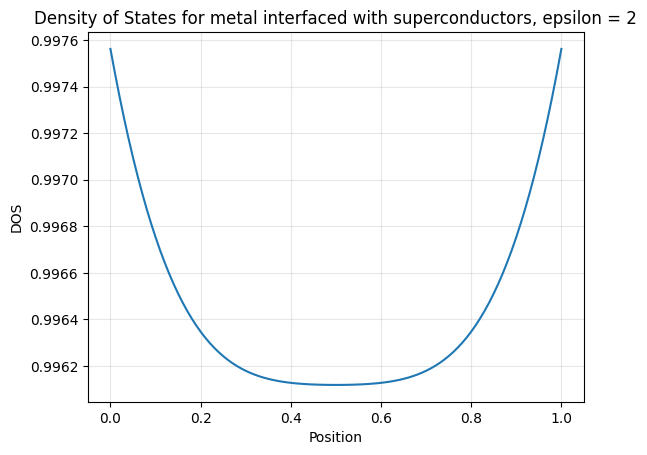

In [ ]:
phi_L = 0
phi_R = 0
epsilon = 2
y = np.zeros((32,m))

sol = solve_usadel_super(l, m, epsilon, phi_L, phi_R, y)
y   = sol.sol(x)

dos_arr = np.zeros(m)

for i in range(m):
    dos_arr[i] = DOS(green_func(y[:,i]))

plt.plot(x, dos_arr)
plt.title(f"Density of States for metal interfaced with superconductors, epsilon = {epsilon}")
plt.xlabel("Position")
plt.ylabel("DOS")
plt.grid(alpha=0.3)
plt.show()

The density of states rises at the interfaces, at position $0$ and position $l$, which is what we expect from the proximity effect.

Comparing with the BCS density of states, the relative density of states is a little above $1$ at $\varepsilon = 2$. This means the DOS is slightly higher than that of a normal metal, and the DOS in the normal metal in between correspondingly becomes higher at the edges, as the superconducting correlations penetrate into the normal region from both sides. Since $\varepsilon$ is well above the gap $|\Delta|$, the effect here is minor and the result stays close to the normal-metal value.


>**Exercise 2k)**

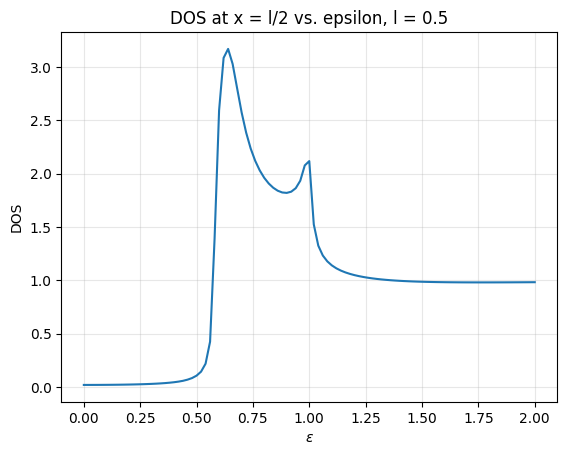

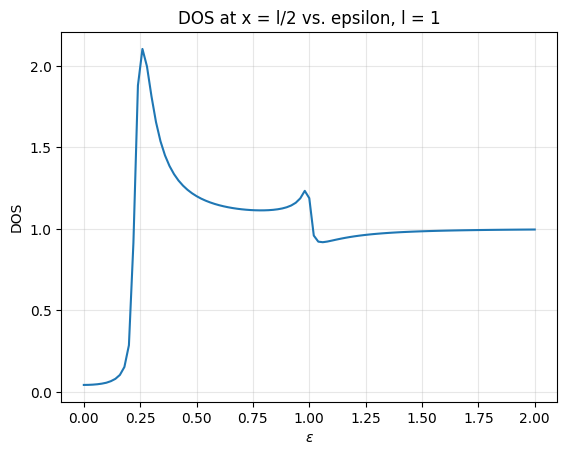

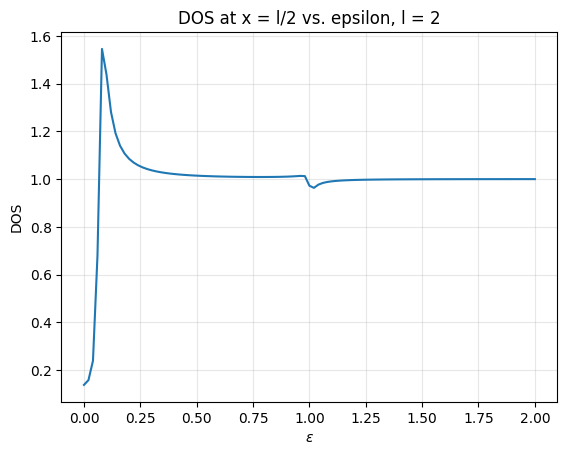

In [ ]:
# To further reduce the runtime, we use this function to parallelize the computationally heavy processes
from concurrent.futures import ProcessPoolExecutor


def simulate_DOS(l):
    """
    Runs the simulation of DOS for a given value of l.
    It iterates over epsilon and returns the density of states (DOS) at x = l/2.

    Variables,
        l : length of the gap (float)

    Returns,
        (l, dos_arr) : A tupel where dos_arr is an array of DOS values for the given l. (tupel)
    """
    x = np.linspace(0,l,m)
    y = np.zeros((32,m))

    dos_arr = np.zeros(m)

    for i, epsilon in enumerate(epsilon_arr): # Looping through all the epsilon in the global epsilon array
        sol        = solve_usadel_super(l, m, epsilon, phi_L, phi_R, y)
        y          = sol.sol(x)
        dos_arr[i] = DOS(green_func(y[:, (m-1)//2 ]))

    return (l, dos_arr)


m = 101
l_arr = [.5, 1, 2]
epsilon_arr = np.linspace(2, 0, m)

phi_L = 0
phi_R = 0

# Parallelizing the computations of DOS for different values of l
with ProcessPoolExecutor() as executor:
    results_dos = list(executor.map(simulate_DOS, l_arr))

for l, dos_arr in results_dos:
    plt.plot(epsilon_arr, dos_arr)
    plt.title(f"DOS at x = l/2 vs. epsilon, l = {l}")
    plt.xlabel(r"$\epsilon$")
    plt.ylabel("DOS")
    plt.grid(alpha=0.3)
    plt.show()

>**Exercise 2l)**

In [ ]:

def green_derived(v):
    """
    Function for calculating the derivative of the given a 32 element vector
    representazation of the Riccati matrices and their derivatives.

    Variables,
        v : 32 element vector with the Riccati matrices (array<float>)

    Returns,
        d_green : 4x4 complex matix representing the derivative of the green function (array<array>)
    """
    gamma, gamma_tilde, omega, omega_tilde = decompact_riccati(v)

    # Calculating N and N_tilde and their derivatives
    N       = np.linalg.inv(I - (gamma @ gamma_tilde))
    N_tilde = np.linalg.inv(I - (gamma_tilde @ gamma))

    d_N       = N @ ((omega @ gamma_tilde + gamma @ omega_tilde) @ N)
    d_N_tilde = N_tilde @ ((omega_tilde @ gamma + gamma_tilde @ omega) @ N_tilde)

    # Calculating the components of the derivative of the greenfunction
    m1 = d_N
    m2 = N @ omega + d_N @ gamma
    m3 = -N_tilde @ omega_tilde - d_N_tilde @ gamma_tilde
    m4 = -d_N_tilde

    # Combining the components to form teh derivative
    d_green = 2*np.block([[ m1 , m2 ],[ m3 , m4 ]])
    return d_green



def current_integrand(v):
    """
    Calculating the current integrand for a given 32 element vector representing
    the Riccati matrecies and their derivatives.

    Variables,
        v : 32 element vector with the Riccati matrices (array<float>)

    Returns,
        j : the current integrand for the given state (float)
    """
    rho_3 = np.block([[ I, np.zeros((2,2)) ], [ np.zeros((2,2)), -I ]]) # Defining rho_3 as in the exercise sheet

    green   = green_func(v)
    d_green = green_derived(v)

    # Calculating the current integrand as defined in the exercise sheet
    j = np.real(np.trace(rho_3 @ (green @ d_green - d_green @ green)))
    return j

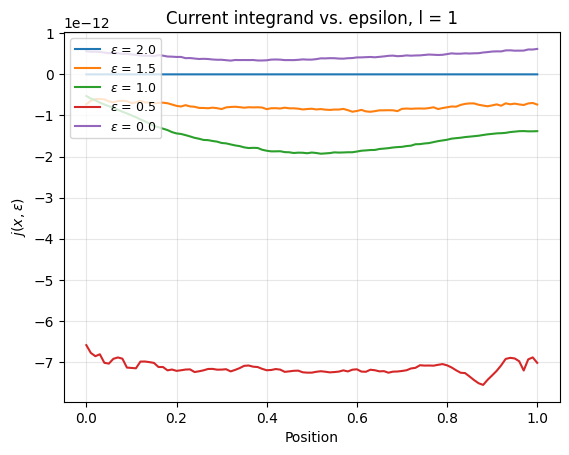

In [ ]:
m     = 101
l     = 1
phi_L = 0
phi_R = 0

x = np.linspace(0,l,m)
y = np.zeros((32,m))

epsilon_arr = np.linspace(2, 0, m)

for i, epsilon in enumerate(epsilon_arr): # Looping over all epsilon

    sol = solve_usadel_super(l, m, epsilon, phi_L, phi_R, y)
    y = sol.sol(x) # Compute solution once per epsilon and use this solution as the initial guess for the next epsilon

    # The epsilon asked to be evaluated in the task will be at each 25 inecies
    if i % 25 == 0:
        j_arr = np.zeros(m)

        for k in range(m):
            j_arr[k] = current_integrand(y[:,k])

        plt.plot(x, j_arr, label = r"$\epsilon$ = " + f"{epsilon}")

plt.title(f"Current integrand vs. epsilon, l = {l}")
plt.xlabel("Position")
plt.ylabel(r"$j(x,\epsilon)$")
plt.grid(alpha=0.3)
plt.legend(loc = "upper left", fontsize = 9)
plt.show()

Deviance from zero may be caused by floating point error in number representation

>**Exercise 2m)**

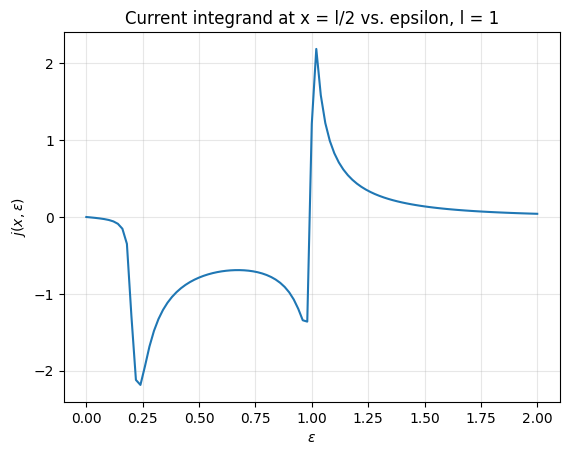

In [ ]:
m = 101
l = 1
epsilon_arr = np.linspace(2, 0, m)

phi_L = 1
phi_R = 0

x = np.linspace(0,l,m)
y = np.zeros((32,m))

j_arr = np.zeros(m)

for i, epsilon in enumerate(epsilon_arr):
    sol      = solve_usadel_super(l, m, epsilon, phi_L, phi_R, y)
    y        = sol.sol(x) # Compute solution once per epsilon and use this solution as the initial guess for the next epsilon
    j_arr[i] = current_integrand(y[:, (m-1)//2 ])


plt.plot(epsilon_arr, j_arr)
plt.title(f"Current integrand at x = l/2 vs. epsilon, l = {l}")
plt.xlabel(r"$\varepsilon$")
plt.ylabel(r"$j(x,\varepsilon)$")
plt.grid(alpha=0.3)
plt.show()

Unlike the zero-phase case in exercise 2l), the current integrand is now clearly non-zero for some values of $\varepsilon$. This is expected: a phase difference between the two superconductors allows a supercurrent to flow through the normal metal.

The integrand starts at zero for $\varepsilon = 0$ and grows in absolute value to a maximum near $\varepsilon \approx 0.25$, which is the energy at which the edge of the mini-gap sits in the middle of the metal for $l = 1$. It then decreases until the resonant effects near $\varepsilon \approx 1$ set in, causing a spike before the current changes direction once the energy relative to the Fermi level exceeds the superconducting gap $|\Delta|$. Above this the resonant effects die away quickly and the system loses its ability to carry a supercurrent.

**The current integrand is conserved as a function of position.** Starting from

$$j(x, \varepsilon) = \Re\left\{\mathrm{Tr}\left[\hat{\rho}_3\left(\hat{g}\,\partial_x\hat{g} - (\partial_x\hat{g})\,\hat{g}\right)\right]\right\},$$

and using that both the derivative and the matrix trace are linear,

$$\partial_x j = \Re\left\{\mathrm{Tr}\left[\hat{\rho}_3\left((\partial_x\hat{g})^2 + \hat{g}\,\partial_x^2\hat{g} - (\partial_x^2\hat{g})\,\hat{g} - (\partial_x\hat{g})^2\right)\right]\right\}
= \Re\left\{\mathrm{Tr}\left[\hat{\rho}_3\left(\hat{g}\,\partial_x^2\hat{g} - (\partial_x^2\hat{g})\,\hat{g}\right)\right]\right\}.$$

Applying the cyclic property of the trace to the second term and collecting, this becomes the trace of a commutator,

$$\partial_x j = \Re\left\{\mathrm{Tr}\left[\hat{\rho}_3\hat{g},\ \partial_x^2\hat{g}\right]\right\} = 0,$$

since the trace of a commutator always vanishes. The current is therefore the same at every $x$, which is why it is enough to evaluate it at $x = l/2$ in the next exercise.


>**Exercise 2n)**

Since the current integrand is conserved as a function of position, the current itself is equal for all x, and it suffices to solve for x = l/2.

In [ ]:
from scipy.integrate import simpson

def current(cur_int, epsilon_arr):
    """
    Function for calculating the current using simpsons method on
    an array of current integrand values.

    Variables,
        cur_int     : Array of current integrand values (array<float>)
        epsilon_arr : Array with th evalues of epsilon to integrate over (array<float>)

    Returns,
        c : The numerical value of the current (float)
    """
    c = - simpson(y = cur_int, x = epsilon_arr)
    return c


def simulate_phase(phi_L):
    """
    Runs the simulation for a given phase angle phi_L.
    This function performs the simulation loop over epsilon values
    and returns the computed current.
    """
    x = np.linspace(0, l, m)
    y = np.zeros((32, m))  # initial guess
    j_arr = np.zeros(m)

    for i, epsilon in enumerate(epsilon_arr):
        sol = solve_usadel_super(l, m, epsilon, phi_L, phi_R, y)
        y   = sol.sol(x)  # Compute solution once per epsilon and use this solution as the initial guess for the next epsilon

        j_arr[i] = current_integrand(y[:, (m-1)//2]) # The middle of the normal metal corresponds to the (m-1)//2 index

    # Compute the current by integrating over epsilon (using your current function)
    return current(j_arr, np.flip(epsilon_arr))

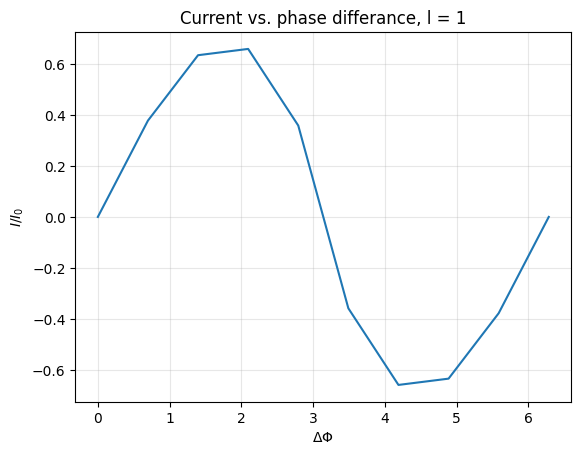

In [ ]:
from math import pi

m = 101
l = 1
epsilon_arr = np.linspace(2, 0, m)

n = 10 # Number of delta Phi we want to use
phi_R = 0
phi_L_arr = np.linspace(0, 2*pi, n)

# Once again parallelizing to reduce runtime
with ProcessPoolExecutor() as executor:
  results = list(executor.map(simulate_phase, phi_L_arr))

current_arr = np.array(results)
plt.plot(phi_L_arr, current_arr)
plt.title(f"Current vs. phase difference, l = {l}")
plt.xlabel(r"$\Delta \Phi$")
plt.ylabel(r"$I/ I_0$")
plt.grid(alpha=0.3)
plt.show()

We observe a sinusoidal, $2\pi$-periodic relationship between the current and the phase difference across the junction.

This is the DC Josephson effect: a supercurrent flows through the normal region driven purely by the phase difference between the two superconductors on either side of it, with no applied voltage.


In [ ]:
stop = time.time()
print(stop - start)

3736.584634780884
